=== CATEGORY DISTRIBUTION (BEFORE BALANCING) ===
DDoS            12,292,065  (58.5%)
DoS              4,178,844  (19.9%)
Mirai            2,359,183  (11.2%)
Benign           1,047,308  (5.0%)
Recon              655,464  (3.1%)
Spoofing           436,061  (2.1%)
Web                 23,707  (0.1%)
BruteForce          12,520  (0.1%)


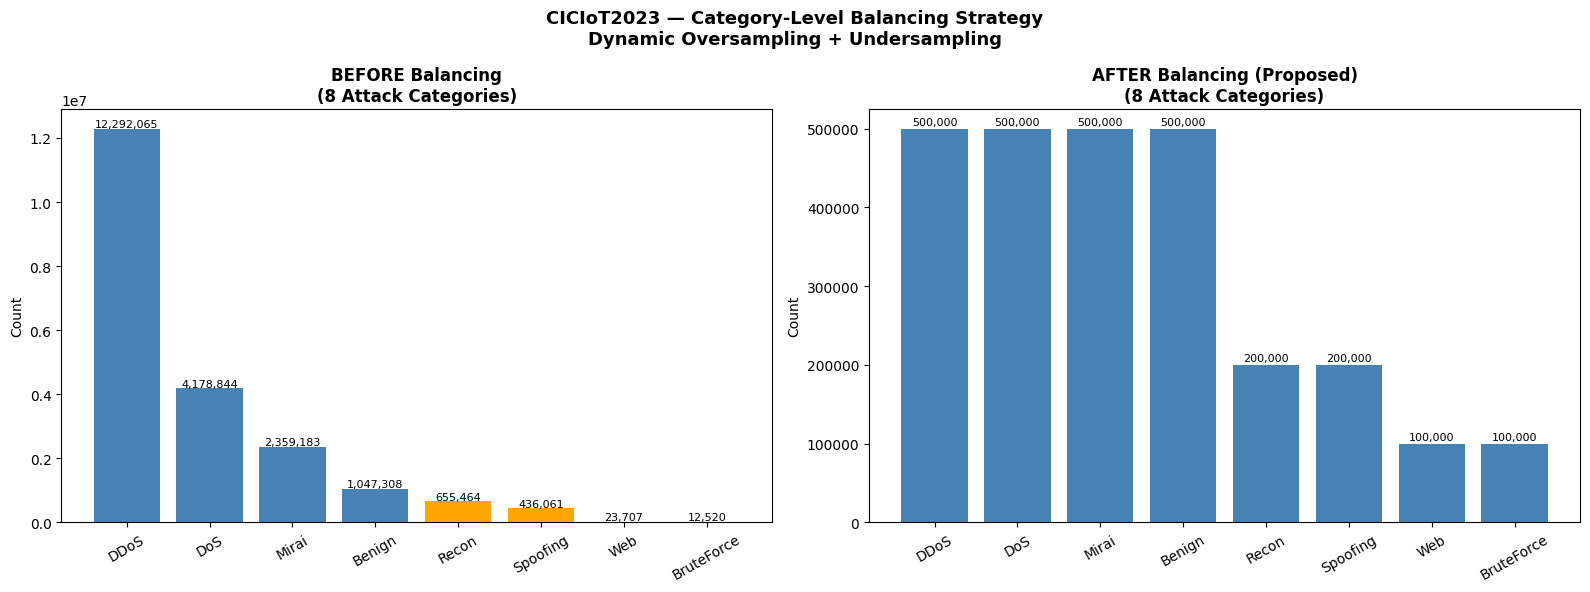

Saved: category_balancing_strategy.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load ONLY Category column — saves ~4.8GB of RAM
df_clean = pd.read_csv('../extracted/ciciot_clean.csv', usecols=['Category'])
cat_counts = df_clean['Category'].value_counts()

print("=== CATEGORY DISTRIBUTION (BEFORE BALANCING) ===")
for cat, count in cat_counts.items():
    pct = count/len(df_clean)*100
    print(f"{cat:<15} {count:>10,}  ({pct:.1f}%)")

# Plot before and after side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_before = ['red' if c < 100000 else 'orange' if c < 1000000 else 'steelblue' 
                 for c in cat_counts.values]
bars = axes[0].bar(cat_counts.index, cat_counts.values, color=colors_before)
axes[0].set_title('BEFORE Balancing\n(8 Attack Categories)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50000,
                f'{val:,}', ha='center', fontsize=8)

target = {
    'DDoS':       500000,
    'DoS':        500000,
    'Mirai':      500000,
    'Benign':     500000,
    'Recon':      200000,
    'Spoofing':   200000,
    'Web':        100000,
    'BruteForce': 100000,
}

bars2 = axes[1].bar(target.keys(), target.values(), color=['steelblue']*8)
axes[1].set_title('AFTER Balancing (Proposed)\n(8 Attack Categories)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, target.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5000,
                f'{val:,}', ha='center', fontsize=8)

plt.suptitle('CICIoT2023 — Category-Level Balancing Strategy\nDynamic Oversampling + Undersampling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('category_balancing_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: category_balancing_strategy.png")

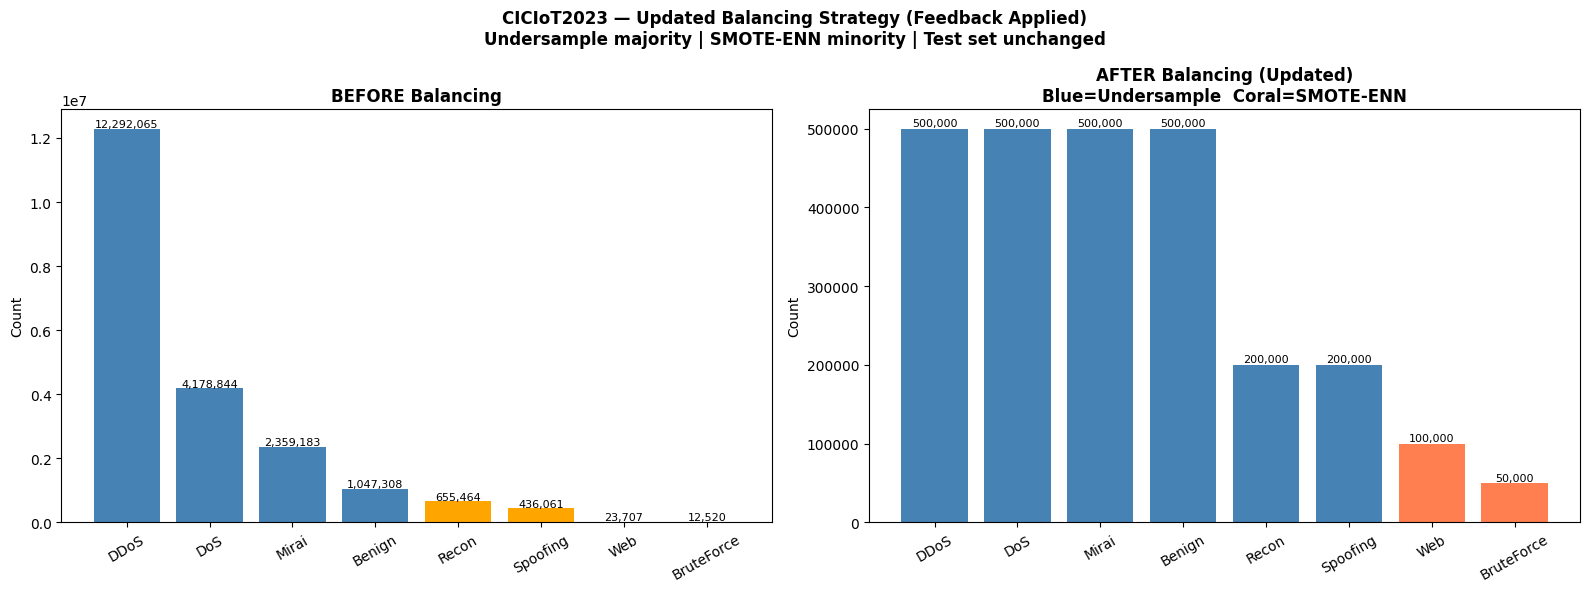

Saved: category_balancing_updated.png


In [4]:
# === UPDATED BALANCING STRATEGY ===
# Incorporating feedback

target_updated = {
    'DDoS':       500000,  # Undersample
    'DoS':        500000,  # Undersample
    'Mirai':      500000,  # Undersample
    'Benign':     500000,  # Undersample
    'Recon':      200000,  # Undersample
    'Spoofing':   200000,  # Undersample
    'Web':        100000,  # SMOTE-ENN (4x ratio)
    'BruteForce':  50000,  # SMOTE-ENN (4x ratio, capped)
}

# Visualize updated strategy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before
cat_counts_sorted = cat_counts.reindex(target_updated.keys())
colors_before = ['steelblue' if c > 1000000 else 'orange' if c > 100000 else 'red'
                 for c in cat_counts_sorted.values]
bars = axes[0].bar(cat_counts_sorted.index, cat_counts_sorted.values, color=colors_before)
axes[0].set_title('BEFORE Balancing', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, cat_counts_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50000,
                f'{val:,}', ha='center', fontsize=8)

# After
colors_after = ['steelblue']*6 + ['coral']*2
bars2 = axes[1].bar(target_updated.keys(), target_updated.values(), color=colors_after)
axes[1].set_title('AFTER Balancing (Updated)\nBlue=Undersample  Coral=SMOTE-ENN',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, target_updated.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3000,
                f'{val:,}', ha='center', fontsize=8)

plt.suptitle('CICIoT2023 — Updated Balancing Strategy (Feedback Applied)\n'
             'Undersample majority | SMOTE-ENN minority | Test set unchanged',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('category_balancing_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: category_balancing_updated.png")